In [ ]:
# Zainstalowanie pakietu Ultralytics
!pip install ultralytics

In [2]:
# Importowanie bibliotek
from ultralytics import YOLO
import cv2, os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Ustawienie katalogu roboczego
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Colab Notebooks/')

Mounted at /content/drive


In [4]:
# Załadowanie modelu
model = YOLO('yolo11n-seg.pt')

In [5]:
# Wyświetlenie informacji o modelu
model.info()

YOLO11n-seg summary: 203 layers, 2,876,848 parameters, 0 gradients, 9.9 GFLOPs


(203, 2876848, 0, 9.900352)

In [6]:
# Uruchomienie trenowania
model.train(data = 'data.yaml', epochs = 50, patience = 10, device = 0)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pos

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bd56901ae10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [7]:
# Ewaluacja modelu na zbiorze testowym
model = YOLO('runs/segment/train/weights/best.pt')
metrics = model.val(split = 'test')

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,958 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 2.7±3.8 ms, read: 0.5±0.4 MB/s, size: 263.0 KB)
val: Scanning /content/drive/My Drive/Colab Notebooks/skin_lesions/labels/test... 225 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 2.3it/s 1:39
val: New cache created: /content/drive/My Drive/Colab Notebooks/skin_lesions/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.4s/it 20.5s
                   all        225        223      0.777      0.727      0.791      0.573      0.772      0.716      0.778      0.535
              Melanoma        100        113      0.788      0.625      0.756      0.542      0.765      0.605      0.729      0.496
                 Nevus        100        110      0.765   

In [8]:
# Predykcja nowych obrazów znajdujących się w katalogu "predict"
results = model('skin_lesions/images/predict')


image 1/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/MI_01.jpg: 640x640 1 Melanoma, 12.0ms
image 2/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/MI_02.jpg: 640x640 1 Melanoma, 24.1ms
image 3/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/MI_03.jpg: 640x640 1 Melanoma, 83.3ms
image 4/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/MI_04.jpg: 640x640 1 Melanoma, 34.7ms
image 5/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/N_01.jpg: 640x640 1 Nevus, 25.6ms
image 6/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/N_02.jpg: 640x640 1 Melanoma, 1 Nevus, 65.1ms
image 7/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/N_03.jpg: 640x640 1 Nevus, 45.8ms
image 8/8 /content/drive/MyDrive/Colab Notebooks/skin_lesions/images/predict/N_04.jpg: 640x640 1 Nevus, 15.8ms
Speed: 10.5ms preprocess, 38.3ms inference, 6.9ms postprocess per image at shape (1

In [9]:
# Utworzenie katalogu do zapisania wyników predykcji
predictions = 'predictions/'
if not os.path.exists(predictions):
  os.mkdir(predictions)

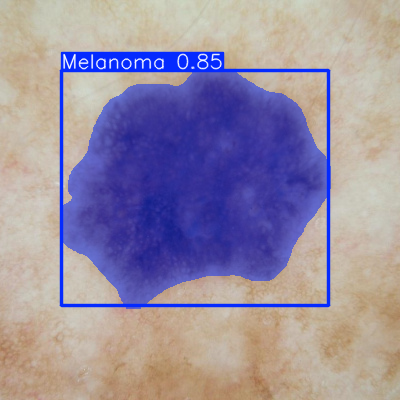

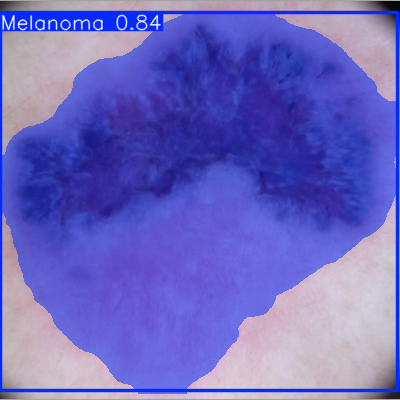

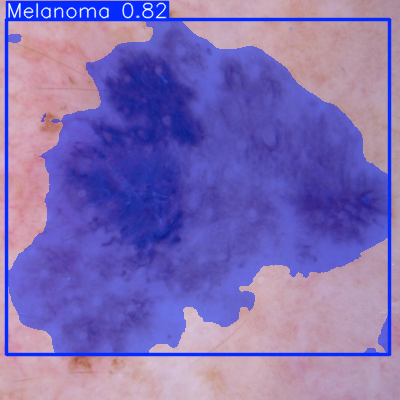

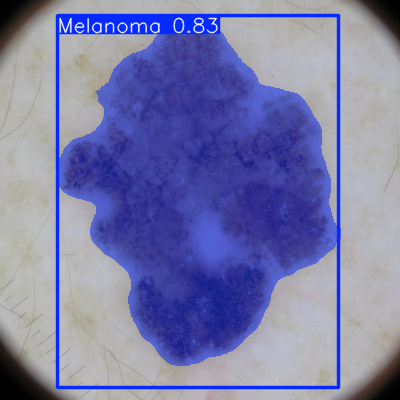

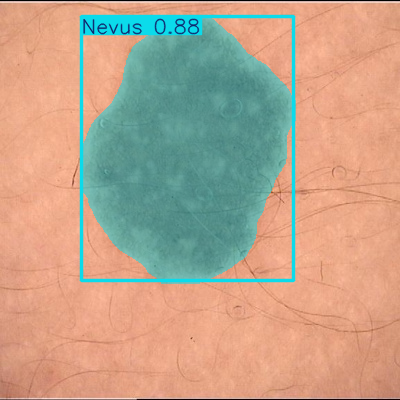

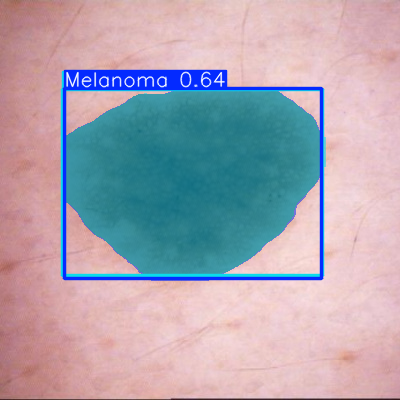

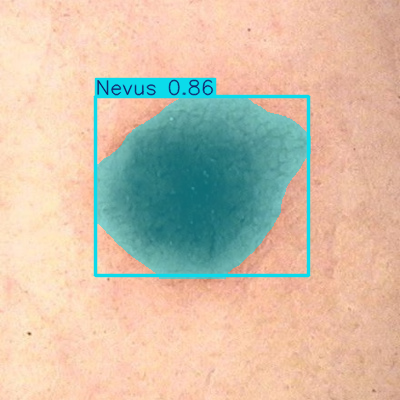

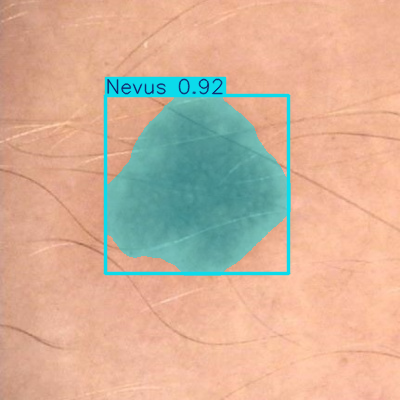

In [10]:
# Wyświetlenie wyników predykcji i zapisanie ich w katalogu "predictions"
for id, result in enumerate(results, 0):
    result.show()
    file_name = os.path.basename(results[id].path)
    result.save(filename = predictions + 'pred_' + file_name)